# Validação visual — tráfego legítimo (modo normal / classe negativa)

Este notebook é material de revisão para a reunião com os orientadores, não
parte do pipeline de produção. Ele valida visualmente o gerador da **classe
negativa** dos datasets de detecção (PLANO §5.2.2/§5.2.4): tráfego de fundo
plausível em Fonte A/B (processos de Poisson homogêneos independentes, sem
cópula) combinado com uma eleição real acontecendo em Fonte C
(`ElectionModel` com `recompensa=0` — sem CSC de compra de voto por trás,
mas com voto de verdade e resultado publicado por seção).

**Importante — este NÃO é o Sanity Check 1.** O Sanity Check 1
(`recompensa=0`, sem `n_candidatos>1`) testa o caso degenerado "nada
acontece": Fonte A/B ficam vazias, Fonte C fica exatamente zero em toda
seção. Este notebook testa o caso realista "há tráfego de fundo e eleição de
verdade, só não há CSC" — um negativo muito mais difícil para um detector,
porque tem sinal de verdade em todas as três fontes, só sem a assinatura de
coordenação adversarial. Os dois cenários coexistem no gerador e servem a
propósitos de teste diferentes (ver `CLAUDE.md`).

**Nota destacada sobre calibração — leia antes de interpretar os números
abaixo:** `taxa` e `volume_medio` de Fonte A/B são placeholders v0, **sem
nenhum valor calibrado**. A ordem de grandeza certa só pode ser decidida
depois que os níveis de λ (baixa/média/alta) do design fatorial tiverem
valores numéricos no gerador — o que ainda não aconteceu. Os valores usados
aqui foram escolhidos só para produzir um gráfico legível, não para
representar uma intensidade realista de tráfego de oráculo.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import kendalltau

from src.generator.layer1_abm import ElectionModel
from src.generator.normal_mode import contagem_por_timestep, gerar_cenario_normal

plt.rcParams["figure.dpi"] = 100
print(f"Projeto em: {PROJECT_ROOT}")

JANELA = 200.0
TAXA_FONTE_A = 1.0          # placeholder v0, nao calibrado
VOLUME_MEDIO_FONTE_A = 1000.0  # placeholder v0, nao calibrado
TAXA_FONTE_B = 0.8          # placeholder v0, nao calibrado

C:\Users\Dell\Desktop\TCC_Projeto\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Projeto em: C:\Users\Dell\Desktop\TCC_Projeto


## 1. Série temporal de Fonte A e Fonte B — inspeção visual

Geramos um cenário completo e plotamos Fonte A (volume monetário por
timestep) e Fonte B (timestamps de ativação) lado a lado. O objetivo é
confirmar visualmente que os dois processos parecem tráfego de chegada
plausível — eventos espalhados ao longo da janela, sem padrão degenerado
(tudo num só timestep, ou perfeitamente regular) — não repetir nenhuma
checagem estatística formal (isso vem nas próximas células).

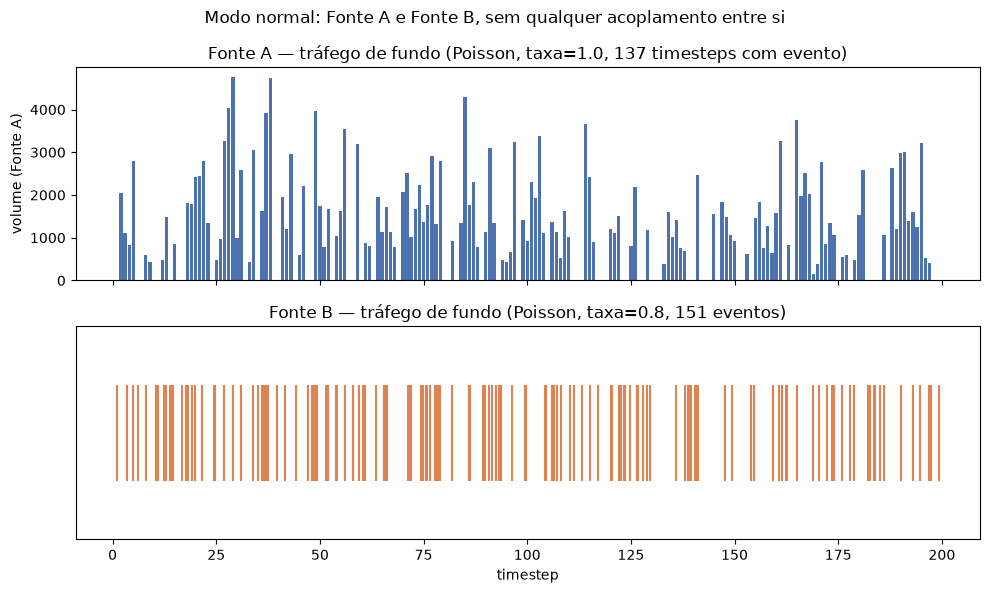

In [2]:
modelo_visual = ElectionModel(n_agentes=800, n_secoes=8, n_candidatos=5, recompensa=0.0, seed=3)
cenario_visual = gerar_cenario_normal(
    modelo_visual, JANELA, TAXA_FONTE_A, VOLUME_MEDIO_FONTE_A, TAXA_FONTE_B,
    random_state_fonte_a=10, random_state_fonte_b=20,
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.bar(cenario_visual.fonte_a["timestep"], cenario_visual.fonte_a["volume"], color="#4C72B0", width=0.8)
ax1.set_ylabel("volume (Fonte A)")
ax1.set_title(f"Fonte A — tráfego de fundo (Poisson, taxa={TAXA_FONTE_A}, {len(cenario_visual.fonte_a)} timesteps com evento)")

ax2.eventplot(cenario_visual.fonte_b, color="#DD8452", linewidths=1.5)
ax2.set_yticks([])
ax2.set_xlabel("timestep")
ax2.set_title(f"Fonte B — tráfego de fundo (Poisson, taxa={TAXA_FONTE_B}, {len(cenario_visual.fonte_b)} eventos)")

fig.suptitle("Modo normal: Fonte A e Fonte B, sem qualquer acoplamento entre si")
fig.tight_layout()
plt.show()

**Leitura:** os eventos de Fonte A (barras azuis, volume monetário) e
Fonte B (traços laranja, timestamps de ativação) aparecem espalhados de
forma irregular ao longo da janela — consistente com dois processos de
Poisson homogêneos, sem qualquer padrão de concentração (o tipo de "pico
apertado" que caracterizaria o modo adversarial com ρ alto, visto no
notebook de conformidade). Note que os dois painéis não têm nenhuma relação
posicional visível entre si — é exatamente esperado, já que usam fluxos de
RNG completamente independentes (`random_state_fonte_a=10`,
`random_state_fonte_b=20`, sementes diferentes e sem qualquer acoplamento
mecânico).

## 2. Distribuição de τ_Kendall(A,B) em várias rodadas independentes

Repetimos a geração de Fonte A/B (mesma janela/taxa, sementes diferentes a
cada rodada) e medimos τ_Kendall(A,B) via `contagem_por_timestep` — o mesmo
binning por janela deslizante usado no teste automatizado
(`test_independencia_fonte_a_e_fonte_b_normal`). Como Fonte A e Fonte B
independentes têm contagens de eventos diferentes em geral, não há
pareamento elemento-a-elemento natural entre elas (ao contrário do caso
acoplado via cópula); binar as duas na mesma grade de timesteps é a forma
como o próprio plano descreve essa métrica (§5.3.1: "τ_Kendall(A,B)
estimado por janela deslizante").

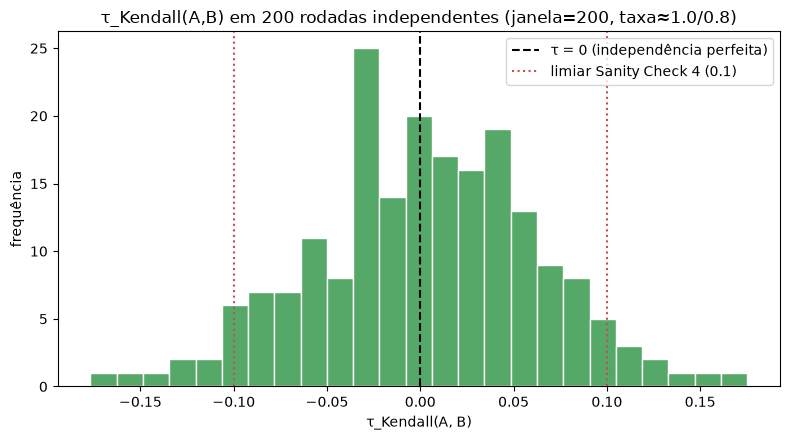

média = 0.0025   desvio-padrão = 0.0604
fração com |τ| < 0.1: 90.50%


In [3]:
n_rodadas = 200
taus = []

for seed in range(n_rodadas):
    from src.generator.normal_mode import gerar_fonte_a_normal, gerar_fonte_b_normal

    fonte_a = gerar_fonte_a_normal(JANELA, TAXA_FONTE_A, VOLUME_MEDIO_FONTE_A, random_state=1000 + seed)
    fonte_b = gerar_fonte_b_normal(JANELA, TAXA_FONTE_B, random_state=2000 + seed)

    timestamps_a = np.repeat(fonte_a["timestep"].to_numpy(dtype=float), fonte_a["n_eventos"].to_numpy())
    contagem_a = contagem_por_timestep(timestamps_a, JANELA)
    contagem_b = contagem_por_timestep(fonte_b, JANELA)

    tau, _ = kendalltau(contagem_a, contagem_b)
    taus.append(tau)

taus = np.array(taus)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(taus, bins=25, color="#55A868", edgecolor="white")
ax.axvline(0, color="black", linestyle="--", label="τ = 0 (independência perfeita)")
ax.axvline(0.1, color="#C44E52", linestyle=":", label="limiar Sanity Check 4 (0.1)")
ax.axvline(-0.1, color="#C44E52", linestyle=":")
ax.set_xlabel("τ_Kendall(A, B)")
ax.set_ylabel("frequência")
ax.set_title(f"τ_Kendall(A,B) em {n_rodadas} rodadas independentes (janela={JANELA:.0f}, taxa≈{TAXA_FONTE_A}/{TAXA_FONTE_B})")
ax.legend()
fig.tight_layout()
plt.show()

print(f"média = {taus.mean():.4f}   desvio-padrão = {taus.std():.4f}")
print(f"fração com |τ| < 0.1: {(np.abs(taus) < 0.1).mean():.2%}")

**Leitura:** o histograma deve ficar centrado em zero e razoavelmente
estreito, com a maioria (idealmente quase todas) das rodadas caindo dentro
das linhas tracejadas vermelhas (±0.1, o limiar do Sanity Check 4). Note que
o **máximo** de τ_Kendall entre muitas rodadas independentes eventualmente
excede qualquer limiar fixo por acaso, mesmo sob independência genuína — é
por isso que o teste automatizado (`test_independencia_fonte_a_e_fonte_b_normal`)
usa a **média** de |τ| como estatística principal, não o máximo de uma única
rodada.

## 3. Resultado eleitoral (Fonte C) do cenário normal, por seção

Mostramos `resultado_por_secao` do mesmo cenário gerado na Célula 1 —
confirmando que a eleição "de verdade" está acontecendo (resultado variando
por seção, refletindo o voto de base `candidato_preferido` de cada agente),
mesmo sem nenhum CSC ativo (`recompensa=0`). Isso só é possível porque o
modelo foi construído com `n_candidatos>1` — com `n_candidatos=1`, o
resultado degeneraria para exatamente zero em toda seção (ver nota em
`CLAUDE.md` sobre a distinção com o Sanity Check 1).

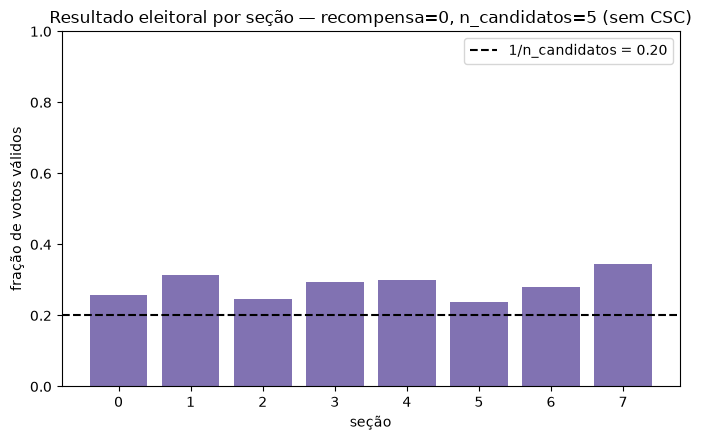

0    0.257732
1    0.314607
2    0.247706
3    0.293478
4    0.300971
5    0.236842
6    0.280899
7    0.345794
Name: fracao_candidato_alvo, dtype: float64

contrato_ativado = None  (None: resolver_desembolso() nunca foi chamado)
eventos_desembolso = []  (vazio: não há CSC nesta amostra)


In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(cenario_visual.resultado_por_secao.index, cenario_visual.resultado_por_secao.values, color="#8172B2")
ax.axhline(1 / modelo_visual.n_candidatos, color="black", linestyle="--", label=f"1/n_candidatos = {1/modelo_visual.n_candidatos:.2f}")
ax.set_xlabel("seção")
ax.set_ylabel("fração de votos válidos")
ax.set_ylim(0, 1.0)
ax.set_title(f"Resultado eleitoral por seção — recompensa=0, n_candidatos={modelo_visual.n_candidatos} (sem CSC)")
ax.legend()
fig.tight_layout()
plt.show()

print(cenario_visual.resultado_por_secao)
print(f"\ncontrato_ativado = {modelo_visual.contrato_ativado}  (None: resolver_desembolso() nunca foi chamado)")
print(f"eventos_desembolso = {modelo_visual.eventos_desembolso}  (vazio: não há CSC nesta amostra)")

**Leitura:** o resultado por seção varia em torno de `1/n_candidatos`
(linha tracejada) — a assinatura esperada de uma eleição sem qualquer
incentivo comprando votos, mas com competição real entre candidatos. Os dois
prints finais confirmam mecanicamente que `resolver_desembolso()` nunca foi
chamado nesta amostra (`contrato_ativado is None`, não `False` — a diferença
importa: `False` significaria "o contrato foi avaliado e não ativou";
`None` significa "não existe contrato aqui").